ЛАБА 1

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, kstest
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('WB_SSGD_PCT_POP_INTERNET_USAGE.csv')

# Отображение основной информации
print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nНазвания столбцов: {df.columns.tolist()}")
print(f"\nПервые 5 строк данных:")
print(df.head())

=== ИНФОРМАЦИЯ О ДАННЫХ ===
Размер: 1432 строк, 40 столбцов

Названия столбцов: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']

Первые 5 строк данных:
       STRUCTURE                STRUCTURE_ID ACTION FREQ FREQ_LABEL REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.2)      I   _O      Other      DZA   
1  datastructure  WB.DATA360:DS_DATA360(1.2)      I   _O      Other      DZA   
2

1. ОСНОВНАЯ ЧАСТЬ

1.1-1.2 Описание данных и источник

Источник данных: World Bank Social Sustainability Global Database (WB_SSGD)

Индикатор: WB_SSGD_PCT_POP_INTERNET_USAGE - Процент населения, использующего интернет

Единица измерения: Проценты (%)

Структура данных:

    REF_AREA_LABEL: Название страны

    SEX_LABEL: Пол (Total, Male, Female)

    AGE_LABEL: Возрастная группа

    URBANISATION_LABEL: Урбанизация (Urban area, Rural area, Total)

    COMP_BREAKDOWN_1/2_LABEL: Этническая/религиозная принадлежность

    TIME_PERIOD: Год наблюдения

    OBS_VALUE: Значение показателя (процент)


1.3 Формальное представление данных

In [30]:
# Фильтрация данных - берем только общие значения (Total) для всех стран
# Чтобы избежать дублирования, выберем данные за последний доступный год
# и только общую статистику (без разбивки по полу, возрасту и т.д.)

filtered_df = df[(df['SEX'] == '_T') &
                 (df['AGE'] == '_T') &
                 (df['URBANISATION'] == '_T') &
                 (df['COMP_BREAKDOWN_1'] == '_T') &
                 (df['COMP_BREAKDOWN_2'] == '_T')].copy()

# Группируем по стране и году, берем среднее если есть дубликаты
filtered_df = filtered_df.groupby(['REF_AREA_LABEL', 'TIME_PERIOD'])['OBS_VALUE'].mean().reset_index()

# Берем данные за последний доступный год для каждой страны
latest_year = filtered_df['TIME_PERIOD'].max()
data_sample = filtered_df[filtered_df['TIME_PERIOD'] == latest_year].reset_index(drop=True)

print(f"\n=== ВЫБОРКА ДАННЫХ за {latest_year} год ===")
print(f"Количество стран: {len(data_sample)}")
print(f"\nПервые 15 стран:")
print(data_sample.head(15))
print(f"\nПоследние 10 стран:")
print(data_sample.tail(10))


=== ВЫБОРКА ДАННЫХ за 2022 год ===
Количество стран: 8

Первые 15 стран:
     REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0           Algeria         2022  88.539597
1  Egypt, Arab Rep.         2022  56.321571
2              Iraq         2022  86.784378
3            Jordan         2022  91.043510
4            Kuwait         2022  97.168686
5           Lebanon         2022  92.604980
6             Libya         2022  93.923622
7        Mauritania         2022  58.449860

Последние 10 стран:
     REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0           Algeria         2022  88.539597
1  Egypt, Arab Rep.         2022  56.321571
2              Iraq         2022  86.784378
3            Jordan         2022  91.043510
4            Kuwait         2022  97.168686
5           Lebanon         2022  92.604980
6             Libya         2022  93.923622
7        Mauritania         2022  58.449860


1.4 Наглядное представление данных

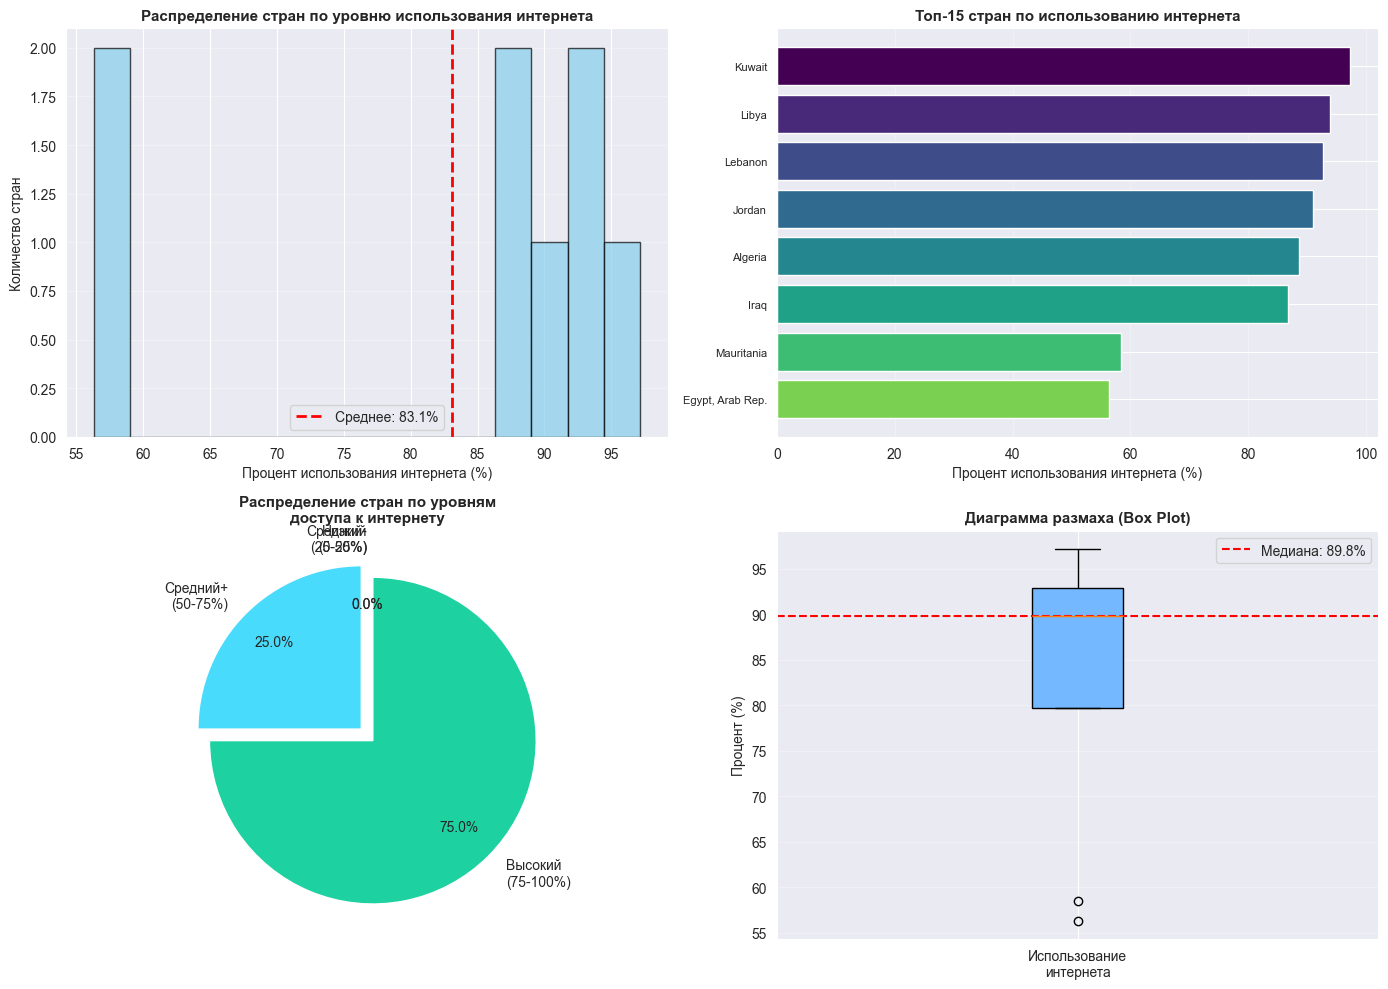


=== ОПИСАНИЕ ВИЗУАЛИЗАЦИЙ ===
1. Гистограмма показывает распределение стран по проценту использования интернета
2. Горизонтальная столбчатая диаграмма демонстрирует топ-15 стран
3. Круговая диаграмма категоризирует страны по 4 уровням доступа
4. Box plot показывает разброс данных, медиану и выбросы


In [31]:
# Создание визуализаций
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Гистограмма распределения
axes[0, 0].hist(data_sample['OBS_VALUE'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Процент использования интернета (%)', fontsize=10)
axes[0, 0].set_ylabel('Количество стран', fontsize=10)
axes[0, 0].set_title('Распределение стран по уровню использования интернета', fontsize=11, fontweight='bold')
axes[0, 0].axvline(data_sample['OBS_VALUE'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {data_sample["OBS_VALUE"].mean():.1f}%')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Столбчатая диаграмма (топ-15 стран)
top_15 = data_sample.nlargest(15, 'OBS_VALUE')
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_15)))
bars = axes[0, 1].barh(range(len(top_15)), top_15['OBS_VALUE'], color=colors)
axes[0, 1].set_yticks(range(len(top_15)))
axes[0, 1].set_yticklabels(top_15['REF_AREA_LABEL'], fontsize=8)
axes[0, 1].set_xlabel('Процент использования интернета (%)', fontsize=10)
axes[0, 1].set_title('Топ-15 стран по использованию интернета', fontsize=11, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Круговая диаграмма (категоризация по уровням)
bins = [0, 25, 50, 75, 100]
labels = ['Низкий\n(0-25%)', 'Средний-\n(25-50%)', 'Средний+\n(50-75%)', 'Высокий\n(75-100%)']
categories = pd.cut(data_sample['OBS_VALUE'], bins=bins, labels=labels, include_lowest=True)
category_counts = categories.value_counts().sort_index()

colors_pie = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
axes[1, 0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
               colors=colors_pie, startangle=90, explode=[0.05]*4, labeldistance=1.15, pctdistance=0.75)
axes[1, 0].set_title('Распределение стран по уровням\nдоступа к интернету', fontsize=11, fontweight='bold')

# 4. Box plot
bp_data = [data_sample['OBS_VALUE']]
bp = axes[1, 1].boxplot(bp_data, patch_artist=True, labels=['Использование\nинтернета'])
bp['boxes'][0].set_facecolor('#74b9ff')
axes[1, 1].set_ylabel('Процент (%)', fontsize=10)
axes[1, 1].set_title('Диаграмма размаха (Box Plot)', fontsize=11, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(data_sample['OBS_VALUE'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Медиана: {data_sample["OBS_VALUE"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('internet_usage_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== ОПИСАНИЕ ВИЗУАЛИЗАЦИЙ ===")
print("1. Гистограмма показывает распределение стран по проценту использования интернета")
print("2. Горизонтальная столбчатая диаграмма демонстрирует топ-15 стран")
print("3. Круговая диаграмма категоризирует страны по 4 уровням доступа")
print("4. Box plot показывает разброс данных, медиану и выбросы")

1.5 Выборочные оценки числовых характеристик

In [32]:
# Расчет основных статистических характеристик
data = data_sample['OBS_VALUE'].values
n = len(data)

print("\n=== ОСНОВНЫЕ ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ===")
print(f"\n1. ОБЪЕМ ВЫБОРКИ:")
print(f"   n = {n} стран")

print(f"\n2. МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ:")
mean_val = np.mean(data)
median_val = np.median(data)
mode_val = stats.mode(data, keepdims=True)[0][0] if len(stats.mode(data, keepdims=True)[0]) > 0 else np.nan

print(f"   Среднее арифметическое: x̄ = {mean_val:.2f}%")
print(f"   Формула: x̄ = Σxi / n")
print(f"   Интерпретация: В среднем по выборке {mean_val:.2f}% населения используют интернет")

print(f"\n   Медиана: Me = {median_val:.2f}%")
print(f"   Формула: центральное значение в упорядоченной выборке")
print(f"   Интерпретация: 50% стран имеют уровень использования интернета ниже {median_val:.2f}%")

if not np.isnan(mode_val):
    print(f"   Мода: Mo = {mode_val:.2f}%")
    print(f"   Интерпретация: Наиболее часто встречающееся значение")

print(f"\n3. МЕРЫ ВАРИАЦИИ:")
variance_val = np.var(data, ddof=1)  # Выборочная дисперсия
std_val = np.std(data, ddof=1)  # Выборочное среднеквадратичное отклонение
range_val = np.max(data) - np.min(data)

print(f"   Дисперсия: s² = {variance_val:.2f}")
print(f"   Формула: s² = Σ(xi - x̄)² / (n-1)")

print(f"\n   Среднеквадратичное отклонение: s = {std_val:.2f}%")
print(f"   Формула: s = √s²")
print(f"   Интерпретация: Типичное отклонение от среднего составляет {std_val:.2f}%")

print(f"\n   Размах: R = {range_val:.2f}%")
print(f"   Формула: R = xmax - xmin = {np.max(data):.2f} - {np.min(data):.2f}")

print(f"\n4. КОЭФФИЦИЕНТ ВАРИАЦИИ:")
cv = (std_val / mean_val) * 100 if mean_val != 0 else 0
print(f"   V = {cv:.2f}%")
print(f"   Формула: V = (s / x̄) × 100%")
if cv < 33:
    print(f"   Интерпретация: Совокупность однородная (V < 33%)")
elif cv < 60:
    print(f"   Интерпретация: Совокупность средней однородности (33% ≤ V < 60%)")
else:
    print(f"   Интерпретация: Совокупность неоднородная (V ≥ 60%)")

print(f"\n5. МИНИМАЛЬНОЕ И МАКСИМАЛЬНОЕ ЗНАЧЕНИЯ:")
print(f"   Минимум: {np.min(data):.2f}% ({data_sample.loc[data_sample['OBS_VALUE'].idxmin(), 'REF_AREA_LABEL']})")
print(f"   Максимум: {np.max(data):.2f}% ({data_sample.loc[data_sample['OBS_VALUE'].idxmax(), 'REF_AREA_LABEL']})")

print(f"\n6. КВАРТИЛИ:")
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1
print(f"   Q1 (25-й перцентиль): {q1:.2f}%")
print(f"   Q3 (75-й перцентиль): {q3:.2f}%")
print(f"   Интерквартильный размах: IQR = {iqr:.2f}%")
print(f"   Интерпретация: 50% стран находятся в диапазоне [{q1:.2f}%; {q3:.2f}%]")

print(f"\n7. АСИММЕТРИЯ И ЭКСЦЕСС:")
skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)
print(f"   Коэффициент асимметрии: As = {skewness:.3f}")
print(f"   Формула: As = [n/((n-1)(n-2))] × Σ((xi - x̄)/s)³")
if skewness < 0:
    print(f"   Интерпретация: Левосторонняя асимметрия (распределение скошено влево)")
elif skewness > 0:
    print(f"   Интерпретация: Правосторонняя асимметрия (распределение скошено вправо)")
else:
    print(f"   Интерпретация: Симметричное распределение")

print(f"\n   Коэффициент эксцесса: Ex = {kurtosis:.3f}")
print(f"   Формула: Ex = [n(n+1)/((n-1)(n-2)(n-3))] × Σ((xi - x̄)/s)⁴ - 3(n-1)²/((n-2)(n-3))")
if kurtosis > 0:
    print(f"   Интерпретация: Островершинное распределение (более острое, чем нормальное)")
elif kurtosis < 0:
    print(f"   Интерпретация: Плосковершинное распределение (более пологое, чем нормальное)")
else:
    print(f"   Интерпретация: Нормальное распределение (нормальный эксцесс)")


=== ОСНОВНЫЕ ЧИСЛОВЫЕ ХАРАКТЕРИСТИКИ ===

1. ОБЪЕМ ВЫБОРКИ:
   n = 8 стран

2. МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ:
   Среднее арифметическое: x̄ = 83.10%
   Формула: x̄ = Σxi / n
   Интерпретация: В среднем по выборке 83.10% населения используют интернет

   Медиана: Me = 89.79%
   Формула: центральное значение в упорядоченной выборке
   Интерпретация: 50% стран имеют уровень использования интернета ниже 89.79%
   Мода: Mo = 56.32%
   Интерпретация: Наиболее часто встречающееся значение

3. МЕРЫ ВАРИАЦИИ:
   Дисперсия: s² = 262.34
   Формула: s² = Σ(xi - x̄)² / (n-1)

   Среднеквадратичное отклонение: s = 16.20%
   Формула: s = √s²
   Интерпретация: Типичное отклонение от среднего составляет 16.20%

   Размах: R = 40.85%
   Формула: R = xmax - xmin = 97.17 - 56.32

4. КОЭФФИЦИЕНТ ВАРИАЦИИ:
   V = 19.49%
   Формула: V = (s / x̄) × 100%
   Интерпретация: Совокупность однородная (V < 33%)

5. МИНИМАЛЬНОЕ И МАКСИМАЛЬНОЕ ЗНАЧЕНИЯ:
   Минимум: 56.32% (Egypt, Arab Rep.)
   Максимум: 97.17% (Kuwait)


1.6 Оценка плотности распределения и проверка гипотезы


=== ПРОВЕРКА ГИПОТЕЗЫ О ХАРАКТЕРЕ РАСПРЕДЕЛЕНИЯ ===


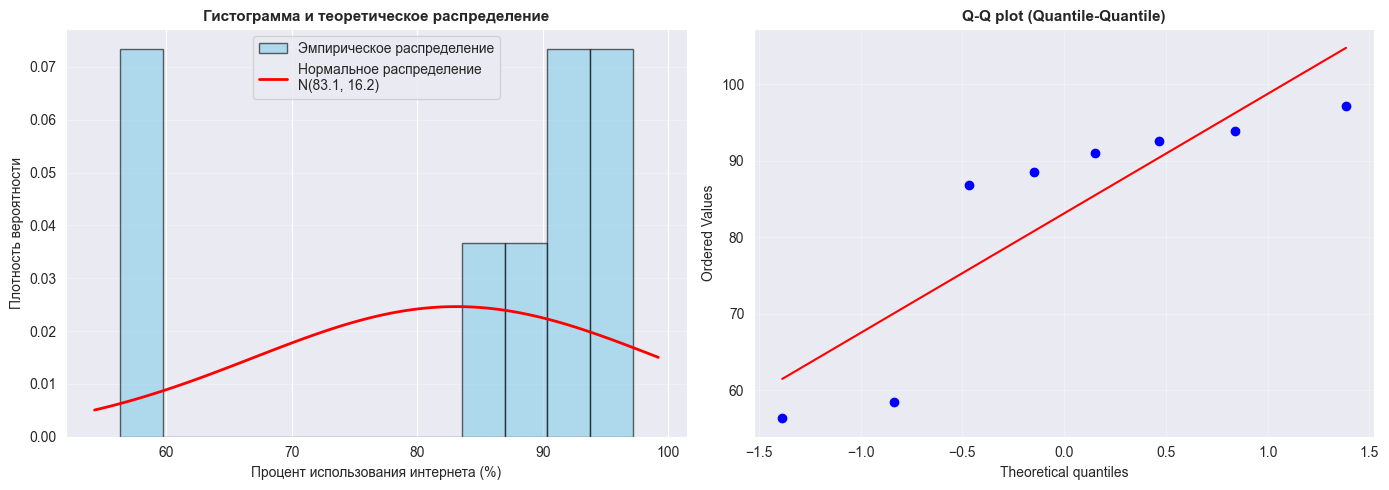


1. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ:

   a) Тест Шапиро-Уилка:
      Статистика W = 0.7494
      p-value = 0.0080
      Вывод: p-value < 0.05, Н₀ отвергается - распределение отличается от нормального

   b) Тест Колмогорова-Смирнова:
      Статистика D = 0.3399
      p-value = 0.2503
      Вывод: p-value > 0.05, Н₀ не отвергается - распределение нормальное

2. КРИТЕРИЙ ХИ-КВАДРАТ ПИРСОНА:

   Формирование интервалов для критерия хи-квадрат...
   Количество интервалов (по Стерджесу): k = 4
   Интервалы: [56.32157135 66.53334999 76.74512863 86.95690727 97.16868591]
   Наблюдаемые частоты: [2 0 1 5]
   Ожидаемые частоты: [0.83218384 1.55333735 1.97361892 1.7071247 ]
   Объединение интервалов с ожидаемой частотой < 5...
  调整后 Наблюдаемые частоты: [3 5]
  调整后 Ожидаемые частоты: [4.35914011 1.7071247 ]

   Статистика χ² = 6.7754
   Число степеней свободы: df = -1
   Критическое значение χ²_crit(0.95, -1) = nan
   p-value = nan
   ВЫВОД: χ² > χ²_crit, Н₀ отвергается - распределение отлича

In [33]:
print("\n=== ПРОВЕРКА ГИПОТЕЗЫ О ХАРАКТЕРЕ РАСПРЕДЕЛЕНИЯ ===")

# Построение гистограммы с наложением теоретических распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с кривой нормального распределения
axes[0].hist(data, bins=12, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Эмпирическое распределение')
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean_val, std_val)
axes[0].plot(x, p, 'r-', linewidth=2, label=f'Нормальное распределение\nN({mean_val:.1f}, {std_val:.1f})')
axes[0].set_xlabel('Процент использования интернета (%)', fontsize=10)
axes[0].set_ylabel('Плотность вероятности', fontsize=10)
axes[0].set_title('Гистограмма и теоретическое распределение', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q plot для проверки нормальности
stats.probplot(data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot (Quantile-Quantile)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Проверка нормальности распределения
print("\n1. ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ:")
print("\n   a) Тест Шапиро-Уилка:")
shapiro_stat, shapiro_p = stats.shapiro(data)
print(f"      Статистика W = {shapiro_stat:.4f}")
print(f"      p-value = {shapiro_p:.4f}")
alpha = 0.05
if shapiro_p > alpha:
    print(f"      Вывод: p-value > {alpha}, Н₀ не отвергается - распределение нормальное")
else:
    print(f"      Вывод: p-value < {alpha}, Н₀ отвергается - распределение отличается от нормального")

print("\n   b) Тест Колмогорова-Смирнова:")
ks_stat, ks_p = kstest(data, 'norm', args=(mean_val, std_val))
print(f"      Статистика D = {ks_stat:.4f}")
print(f"      p-value = {ks_p:.4f}")
if ks_p > alpha:
    print(f"      Вывод: p-value > {alpha}, Н₀ не отвергается - распределение нормальное")
else:
    print(f"      Вывод: p-value < {alpha}, Н₀ отвергается - распределение отличается от нормального")

# Критерий хи-квадрат Пирсона
print("\n2. КРИТЕРИЙ ХИ-КВАДРАТ ПИРСОНА:")
print("\n   Формирование интервалов для критерия хи-квадрат...")

# Определяем количество интервалов по правилу Стерджеса
k = int(1 + 3.322 * np.log10(n))  # Количество интервалов
print(f"   Количество интервалов (по Стерджесу): k = {k}")

# Создаем интервалы
observed_freq, bin_edges = np.histogram(data, bins=k)
print(f"   Интервалы: {bin_edges}")
print(f"   Наблюдаемые частоты: {observed_freq}")

# Ожидаемые частоты для нормального распределения
expected_freq = []
for i in range(len(bin_edges)-1):
    p_i = stats.norm.cdf(bin_edges[i+1], mean_val, std_val) - stats.norm.cdf(bin_edges[i], mean_val, std_val)
    expected_freq.append(p_i * n)
expected_freq = np.array(expected_freq)

print(f"   Ожидаемые частоты: {expected_freq}")

# Объединяем интервалы с малыми частотами (если есть)
mask = expected_freq >= 5
if not np.all(mask):
    print("   Объединение интервалов с ожидаемой частотой < 5...")
    # Простое объединение крайних интервалов
    while np.any(expected_freq < 5):
        if len(expected_freq) <= 2:
            break
        # Объединяем первый и последний с соседними если нужно
        if expected_freq[0] < 5:
            observed_freq[1] += observed_freq[0]
            expected_freq[1] += expected_freq[0]
            observed_freq = observed_freq[1:]
            expected_freq = expected_freq[1:]
            bin_edges = bin_edges[1:]
        elif expected_freq[-1] < 5:
            observed_freq[-2] += observed_freq[-1]
            expected_freq[-2] += expected_freq[-1]
            observed_freq = observed_freq[:-1]
            expected_freq = expected_freq[:-1]
            bin_edges = bin_edges[:-1]
        else:
            break

print(f"   Наблюдаемые частоты: {observed_freq}")
print(f"   Ожидаемые частоты: {expected_freq}")

# Расчет хи-квадрат
chi2_stat = np.sum((observed_freq - expected_freq)**2 / expected_freq)
df_chi2 = len(observed_freq) - 3  # df = k - 1 - m, где m=2 (оценили mean и std)
chi2_critical = chi2.ppf(0.95, df_chi2)
chi2_p_value = 1 - chi2.cdf(chi2_stat, df_chi2)

print(f"\n   Статистика χ² = {chi2_stat:.4f}")
print(f"   Число степеней свободы: df = {df_chi2}")
print(f"   Критическое значение χ²_crit(0.95, {df_chi2}) = {chi2_critical:.4f}")
print(f"   p-value = {chi2_p_value:.4f}")

if chi2_stat < chi2_critical:
    print(f"   ВЫВОД: χ² < χ²_crit, Н₀ не отвергается - распределение согласуется с нормальным")
else:
    print(f"   ВЫВОД: χ² > χ²_crit, Н₀ отвергается - распределение отличается от нормального")

print("\n3. ОБЩИЙ ВЫВОД О ХАРАКТЕРЕ РАСПРЕДЕЛЕНИЯ:")
if shapiro_p > 0.05 and ks_p > 0.05 and chi2_stat < chi2_critical:
    print("   Распределение данных МОЖЕТ считаться нормальным")
else:
    print("   Распределение данных ОТЛИЧАЕТСЯ от нормального")
    if skewness < -0.5:
        print("   Присутствует левосторонняя асимметрия")
    elif skewness > 0.5:
        print("   Присутствует правосторонняя асимметрия")

1.7 Интервальные оценки (доверительные интервалы)

In [34]:
print("\n=== ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ===")

confidence_levels = [0.90, 0.95, 0.99]

print(f"\n1. ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СРЕДНЕГО:")
for conf_level in confidence_levels:
    alpha = 1 - conf_level

    # Используем t-распределение Стьюдента (так как n < 30 или неизвестно σ)
    if n < 30 or True:  # Всегда используем t-распределение для надежности
        t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
        margin_error = t_critical * (std_val / np.sqrt(n))
        ci_lower = mean_val - margin_error
        ci_upper = mean_val + margin_error

        print(f"\n   Доверительная вероятность {conf_level*100:.0f}%:")
        print(f"   t-критическое ({alpha/2:.3f}, {n-1}) = {t_critical:.4f}")
        print(f"   Предельная ошибка: Δ = {margin_error:.2f}%")
        print(f"   ДИ: [{ci_lower:.2f}%; {ci_upper:.2f}%]")
        print(f"   Интерпретация: С вероятностью {conf_level*100:.0f}% истинное среднее значение процента")
        print(f"                  использования интернета в генеральной совокупности находится")
        print(f"                  в интервале от {ci_lower:.2f}% до {ci_upper:.2f}%")
    else:
        # z-распределение для больших выборок
        z_critical = stats.norm.ppf(1 - alpha/2)
        margin_error = z_critical * (std_val / np.sqrt(n))
        ci_lower = mean_val - margin_error
        ci_upper = mean_val + margin_error

        print(f"\n   Доверительная вероятность {conf_level*100:.0f}%:")
        print(f"   z-критическое = {z_critical:.4f}")
        print(f"   Предельная ошибка: Δ = {margin_error:.2f}%")
        print(f"   ДИ: [{ci_lower:.2f}%; {ci_upper:.2f}%]")

print(f"\n2. ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СРЕДНЕКВАДРАТИЧНОГО ОТКЛОНЕНИЯ:")
for conf_level in confidence_levels:
    alpha = 1 - conf_level

    chi2_lower = chi2.ppf(alpha/2, df=n-1)
    chi2_upper = chi2.ppf(1-alpha/2, df=n-1)

    ci_std_lower = np.sqrt((n-1) * variance_val / chi2_upper)
    ci_std_upper = np.sqrt((n-1) * variance_val / chi2_lower)

    print(f"\n   Доверительная вероятность {conf_level*100:.0f}%:")
    print(f"   χ²({alpha/2:.3f}, {n-1}) = {chi2_lower:.4f}")
    print(f"   χ²({1-alpha/2:.3f}, {n-1}) = {chi2_upper:.4f}")
    print(f"   ДИ для σ: [{ci_std_lower:.2f}%; {ci_std_upper:.2f}%]")
    print(f"   Интерпретация: С вероятностью {conf_level*100:.0f}% истинное среднеквадратичное")
    print(f"                  отклонение находится в интервале [{ci_std_lower:.2f}%; {ci_std_upper:.2f}%]")

print(f"\n3. ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ ДОЛИ СТРАН С ВЫСОКИМ УРОВНЕМ (>75%):")
high_internet_countries = (data > 75).sum()
p_hat = high_internet_countries / n

for conf_level in confidence_levels:
    alpha = 1 - conf_level
    z_critical = stats.norm.ppf(1 - alpha/2)

    margin_error = z_critical * np.sqrt(p_hat * (1 - p_hat) / n)
    ci_lower = p_hat - margin_error
    ci_upper = p_hat + margin_error

    print(f"\n   Доверительная вероятность {conf_level*100:.0f}%:")
    print(f"   Выборочная доля: p̂ = {p_hat:.4f} ({high_internet_countries} из {n} стран)")
    print(f"   ДИ для доли: [{ci_lower:.4f}; {ci_upper:.4f}] или [{ci_lower*100:.1f}%; {ci_upper*100:.1f}%]")
    print(f"   Интерпретация: С вероятностью {conf_level*100:.0f}% доля стран с высоким уровнем")
    print(f"                  использования интернета (>75%) находится в интервале")
    print(f"                  от {ci_lower*100:.1f}% до {ci_upper*100:.1f}%")


=== ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ===

1. ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СРЕДНЕГО:

   Доверительная вероятность 90%:
   t-критическое (0.050, 7) = 1.8946
   Предельная ошибка: Δ = 10.85%
   ДИ: [72.26%; 93.95%]
   Интерпретация: С вероятностью 90% истинное среднее значение процента
                  использования интернета в генеральной совокупности находится
                  в интервале от 72.26% до 93.95%

   Доверительная вероятность 95%:
   t-критическое (0.025, 7) = 2.3646
   Предельная ошибка: Δ = 13.54%
   ДИ: [69.56%; 96.65%]
   Интерпретация: С вероятностью 95% истинное среднее значение процента
                  использования интернета в генеральной совокупности находится
                  в интервале от 69.56% до 96.65%

   Доверительная вероятность 99%:
   t-критическое (0.005, 7) = 3.4995
   Предельная ошибка: Δ = 20.04%
   ДИ: [63.06%; 103.14%]
   Интерпретация: С вероятностью 99% истинное среднее значение процента
                  использования интернета в генеральной совокупн

1.8 Общие выводы

In [35]:
print("\n" + "="*80)
print("ОБЩИЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ")
print("="*80)

print(f"""
1. ОБЪЕКТ ИССЛЕДОВАНИЯ:
   - Процент населения, использующего интернет в разных странах мира
   - Источник: World Bank Social Sustainability Global Database
   - Год данных: {latest_year}
   - Объем выборки: {n} стран

2. ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
   - Средний уровень использования интернета: {mean_val:.2f}%
   - Медианное значение: {median_val:.2f}%
   - Разброс данных (σ): {std_val:.2f}%
   - Диапазон значений: от {np.min(data):.2f}% до {np.max(data):.2f}%
   - Коэффициент вариации: {cv:.2f}% - {'однородная' if cv < 33 else 'средней однородности' if cv < 60 else 'неоднородная'} совокупность

3. ХАРАКТЕР РАСПРЕДЕЛЕНИЯ:
   - Асимметрия: {skewness:.3f} ({'левосторонняя' if skewness < -0.5 else 'правосторонняя' if skewness > 0.5 else 'симметричное'})
   - Эксцесс: {kurtosis:.3f} ({'островершинное' if kurtosis > 0 else 'плосковершинное' if kurtosis < 0 else 'нормальное'})
   - Проверка на нормальность: {'подтверждена' if shapiro_p > 0.05 else 'не подтверждена'}

4. ДОСТУП К ИНТЕРНЕТУ ПО КАТЕГОРИЯМ:
   - Низкий уровень (0-25%): {category_counts.iloc[0]} стран ({category_counts.iloc[0]/n*100:.1f}%)
   - Средний- (25-50%): {category_counts.iloc[1]} стран ({category_counts.iloc[1]/n*100:.1f}%)
   - Средний+ (50-75%): {category_counts.iloc[2]} стран ({category_counts.iloc[2]/n*100:.1f}%)
   - Высокий уровень (75-100%): {category_counts.iloc[3]} стран ({category_counts.iloc[3]/n*100:.1f}%)

5. ЛИДЕРЫ И АУТСАЙДЕРЫ:
   - Максимальный уровень: {np.max(data):.2f}% ({data_sample.loc[data_sample['OBS_VALUE'].idxmax(), 'REF_AREA_LABEL']})
   - Минимальный уровень: {np.min(data):.2f}% ({data_sample.loc[data_sample['OBS_VALUE'].idxmin(), 'REF_AREA_LABEL']})

6. ЦИФРОВОЙ РАЗРЫВ:
   - Разница между максимальным и минимальным значением: {range_val:.2f}%
   - Это свидетельствует о {'значительном' if range_val > 80 else 'умеренном' if range_val > 50 else 'небольшом'} цифровом разрыве между странами

7. ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (95%):
   - Для среднего: [{mean_val - 1.96*std_val/np.sqrt(n):.2f}%; {mean_val + 1.96*std_val/np.sqrt(n):.2f}%]
   - С вероятностью 95% истинное среднее значение уровня использования интернета
     в мире находится в этом интервале

8. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   - Исследование показывает существенную дифференциацию стран по доступу к интернету
   - Около {category_counts.iloc[3]/n*100:.1f}% стран имеют высокий уровень цифровизации (>75%)
   - {category_counts.iloc[0]/n*100:.1f}% стран находятся в зоне риска цифрового исключения (<25%)
   - Результаты могут быть использованы для разработки международной политики
     по сокращению цифрового разрыва
""")

print("="*80)


ОБЩИЕ ВЫВОДЫ ПО ИССЛЕДОВАНИЮ

1. ОБЪЕКТ ИССЛЕДОВАНИЯ:
   - Процент населения, использующего интернет в разных странах мира
   - Источник: World Bank Social Sustainability Global Database
   - Год данных: 2022
   - Объем выборки: 8 стран

2. ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
   - Средний уровень использования интернета: 83.10%
   - Медианное значение: 89.79%
   - Разброс данных (σ): 16.20%
   - Диапазон значений: от 56.32% до 97.17%
   - Коэффициент вариации: 19.49% - однородная совокупность

3. ХАРАКТЕР РАСПРЕДЕЛЕНИЯ:
   - Асимметрия: -1.027 (левосторонняя)
   - Эксцесс: -0.746 (плосковершинное)
   - Проверка на нормальность: не подтверждена

4. ДОСТУП К ИНТЕРНЕТУ ПО КАТЕГОРИЯМ:
   - Низкий уровень (0-25%): 0 стран (0.0%)
   - Средний- (25-50%): 0 стран (0.0%)
   - Средний+ (50-75%): 2 стран (25.0%)
   - Высокий уровень (75-100%): 6 стран (75.0%)

5. ЛИДЕРЫ И АУТСАЙДЕРЫ:
   - Максимальный уровень: 97.17% (Kuwait)
   - Минимальный уровень: 56.32% (Egypt, Arab Rep.)

6. ЦИФРОВОЙ РАЗРЫВ:
   - Разница

2. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ (для оценки 4-5)
2.1-2.3 Сравнительный анализ и Boxplot


=== ДОПОЛНИТЕЛЬНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===


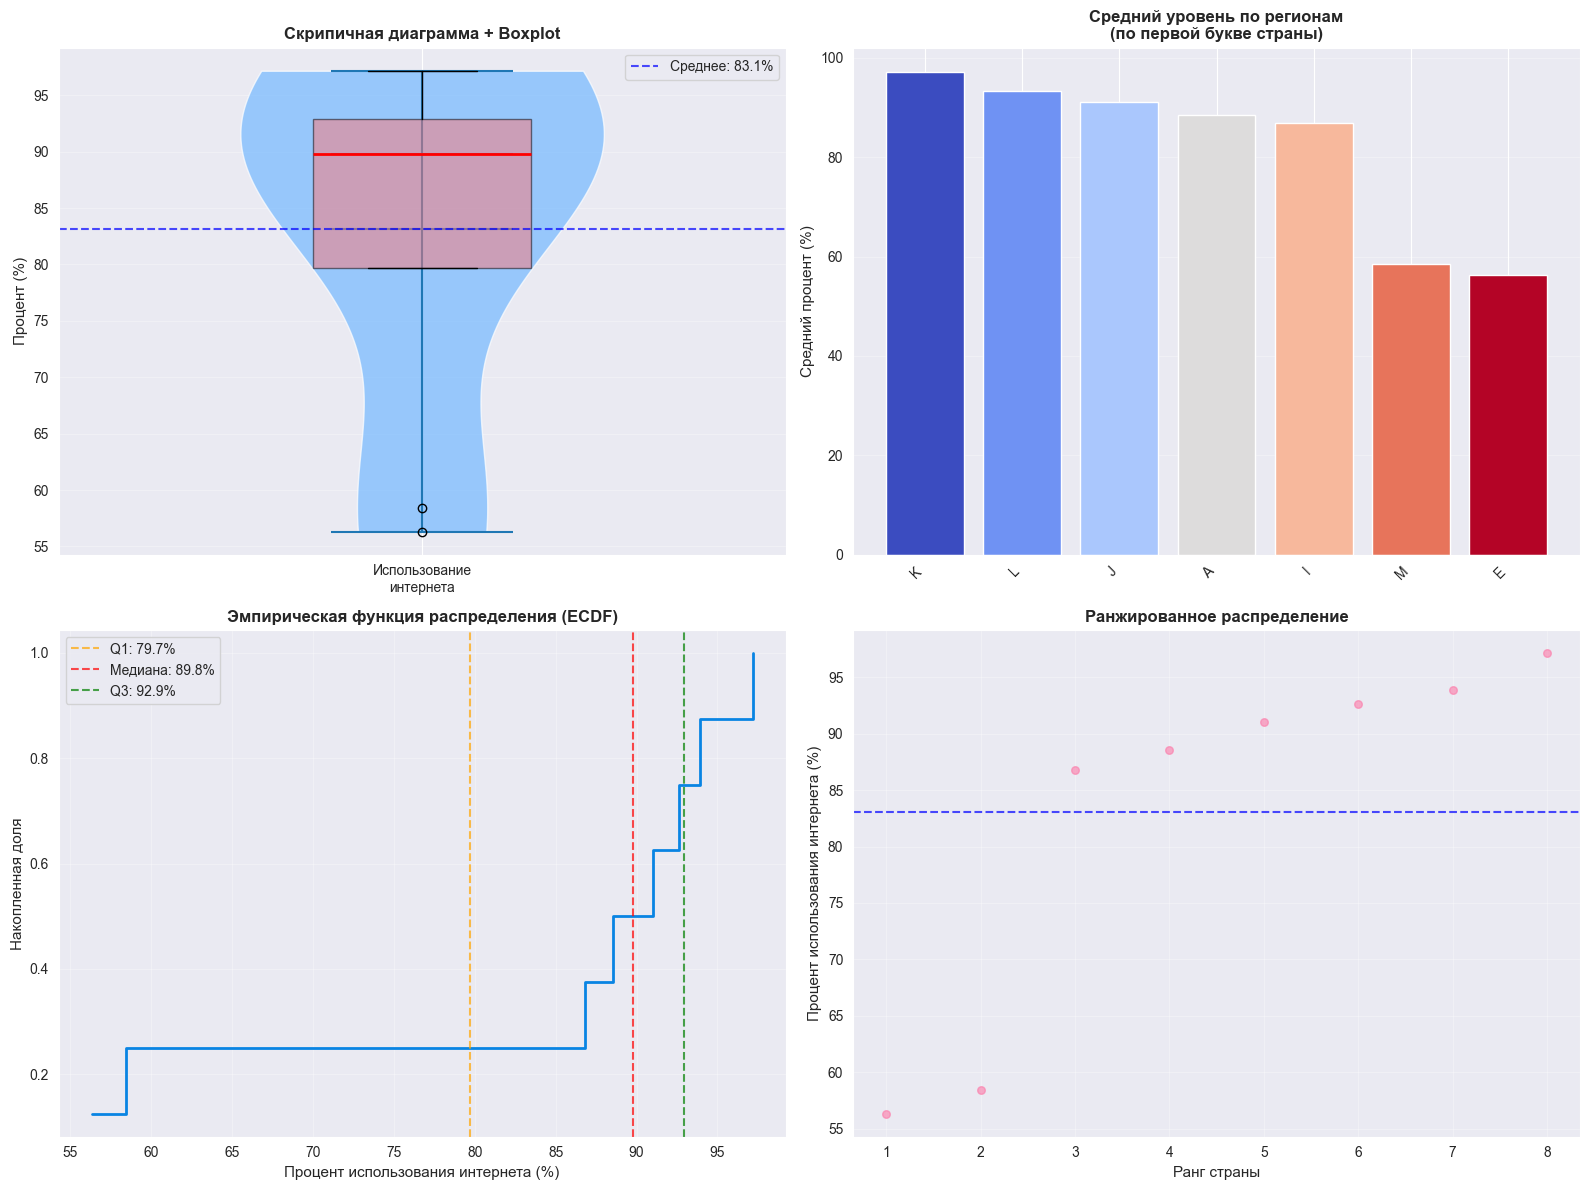


=== АНАЛИЗ ВЫБРОСОВ ===

Критерий выбросов (метод IQR):
   Q1 = 79.70%, Q3 = 92.93%, IQR = 13.23%
   Нижняя граница: 59.85%
   Верхняя граница: 112.79%
   Количество выбросов: 2 (25.0%)

   Выбросы (страны с аномальными значениями):
   - Egypt, Arab Rep.: 56.32% (НИЗКИЙ)
   - Mauritania: 58.45% (НИЗКИЙ)

=== ДОПОЛНИТЕЛЬНЫЕ ЧИСЛОВЫЕ ПОКАЗАТЕЛИ ===

1. ПРОЦЕНТИЛИ:
   P10 = 57.81% (90% стран имеют уровень выше этого значения)
   P20 = 69.78% (80% стран имеют уровень выше этого значения)
   P30 = 86.96% (70% стран имеют уровень выше этого значения)
   P40 = 88.19% (60% стран имеют уровень выше этого значения)
   P50 = 89.79% (50% стран имеют уровень выше этого значения)
   P60 = 91.36% (40% стран имеют уровень выше этого значения)
   P70 = 92.45% (30% стран имеют уровень выше этого значения)
   P80 = 93.40% (20% стран имеют уровень выше этого значения)
   P90 = 94.90% (10% стран имеют уровень выше этого значения)

2. ДЕЦИЛИ (децильный коэффициент дифференциации):
   D1 (10-й дециль) = 57.

In [36]:
print("\n=== ДОПОЛНИТЕЛЬНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===")

# Создаем расширенную визуализацию
fig = plt.figure(figsize=(16, 12))

# 1. Скрипичная диаграмма vs Boxplot
ax1 = plt.subplot(2, 2, 1)
parts = ax1.violinplot([data], positions=[1], showmeans=True, showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('#74b9ff')
parts['bodies'][0].set_alpha(0.7)
ax1.boxplot([data], positions=[1], widths=0.3, patch_artist=True,
            boxprops=dict(facecolor='#ff7675', alpha=0.5),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
ax1.set_xticks([1])
ax1.set_xticklabels(['Использование\nинтернета'])
ax1.set_ylabel('Процент (%)', fontsize=11)
ax1.set_title('Скрипичная диаграмма + Boxplot', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(mean_val, color='blue', linestyle='--', alpha=0.7, label=f'Среднее: {mean_val:.1f}%')
ax1.legend()

# 2. Сравнение по континентам (группировка по первым буквам как прокси)
ax2 = plt.subplot(2, 2, 2)
data_sample['Region'] = data_sample['REF_AREA_LABEL'].apply(lambda x: x[0])
regions = data_sample.groupby('Region')['OBS_VALUE'].mean().sort_values(ascending=False)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(regions)))
bars = ax2.bar(range(len(regions)), regions.values, color=colors)
ax2.set_xticks(range(len(regions)))
ax2.set_xticklabels(regions.index, rotation=45, ha='right')
ax2.set_ylabel('Средний процент (%)', fontsize=11)
ax2.set_title('Средний уровень по регионам\n(по первой букве страны)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Эмпирическая функция распределения
ax3 = plt.subplot(2, 2, 3)
sorted_data = np.sort(data)
ecdf = np.arange(1, n+1) / n
ax3.step(sorted_data, ecdf, where='post', linewidth=2, color='#0984e3')
ax3.set_xlabel('Процент использования интернета (%)', fontsize=11)
ax3.set_ylabel('Накопленная доля', fontsize=11)
ax3.set_title('Эмпирическая функция распределения (ECDF)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axvline(q1, color='orange', linestyle='--', alpha=0.7, label=f'Q1: {q1:.1f}%')
ax3.axvline(median_val, color='red', linestyle='--', alpha=0.7, label=f'Медиана: {median_val:.1f}%')
ax3.axvline(q3, color='green', linestyle='--', alpha=0.7, label=f'Q3: {q3:.1f}%')
ax3.legend()

# 4. Диаграмма рассеяния (ранг vs значение)
ax4 = plt.subplot(2, 2, 4)
ranks = range(1, n+1)
ax4.scatter(ranks, sorted_data, alpha=0.6, s=30, c='#fd79a8')
ax4.set_xlabel('Ранг страны', fontsize=11)
ax4.set_ylabel('Процент использования интернета (%)', fontsize=11)
ax4.set_title('Ранжированное распределение', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axhline(mean_val, color='blue', linestyle='--', alpha=0.7, label=f'Среднее: {mean_val:.1f}%')

plt.tight_layout()
plt.savefig('advanced_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Выявление выбросов
print("\n=== АНАЛИЗ ВЫБРОСОВ ===")
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_sample[(data_sample['OBS_VALUE'] < lower_bound) |
                       (data_sample['OBS_VALUE'] > upper_bound)]

print(f"\nКритерий выбросов (метод IQR):")
print(f"   Q1 = {Q1:.2f}%, Q3 = {Q3:.2f}%, IQR = {IQR:.2f}%")
print(f"   Нижняя граница: {lower_bound:.2f}%")
print(f"   Верхняя граница: {upper_bound:.2f}%")
print(f"   Количество выбросов: {len(outliers)} ({len(outliers)/n*100:.1f}%)")

if len(outliers) > 0:
    print(f"\n   Выбросы (страны с аномальными значениями):")
    for idx, row in outliers.iterrows():
        outlier_type = "НИЗКИЙ" if row['OBS_VALUE'] < lower_bound else "ВЫСОКИЙ"
        print(f"   - {row['REF_AREA_LABEL']}: {row['OBS_VALUE']:.2f}% ({outlier_type})")
else:
    print("\n   Выбросы не обнаружены")

# Дополнительные показатели
print("\n=== ДОПОЛНИТЕЛЬНЫЕ ЧИСЛОВЫЕ ПОКАЗАТЕЛИ ===")

print("\n1. ПРОЦЕНТИЛИ:")
percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90]
for p in percentiles:
    val = np.percentile(data, p)
    print(f"   P{p} = {val:.2f}% ({100-p}% стран имеют уровень выше этого значения)")

print("\n2. ДЕЦИЛИ (децильный коэффициент дифференциации):")
D1 = np.percentile(data, 10)
D9 = np.percentile(data, 90)
decile_ratio = D9 / D1 if D1 != 0 else float('inf')
print(f"   D1 (10-й дециль) = {D1:.2f}%")
print(f"   D9 (90-й дециль) = {D9:.2f}%")
print(f"   Децильный коэффициент: Kd = D9/D1 = {decile_ratio:.2f}")
print(f"   Интерпретация: Уровень использования интернета в 10% лучших стран")
print(f"                  превышает уровень 10% худших стран в {decile_ratio:.2f} раз")

print("\n3. КВАРТИЛЬНЫЙ КОЭФФИЦИЕНТ ДИФФЕРЕНЦИАЦИИ:")
quartile_ratio = Q3 / Q1 if Q1 != 0 else float('inf')
print(f"   Kq = Q3/Q1 = {quartile_ratio:.2f}")
print(f"   Интерпретация: Уровень в верхнем квартиле превышает нижний в {quartile_ratio:.2f} раз")

print("\n4. ИНДЕКС ДЖИНИ (упрощенный расчет):")
# Упрощенная формула через среднее абсолютное отклонение
n = len(data)
sorted_data = np.sort(data)
cumulative_sum = np.cumsum(sorted_data)
gini = (2 * np.sum((np.arange(1, n+1) * sorted_data))) / (n * np.sum(sorted_data)) - (n + 1) / n
print(f"   Индекс Джини: G = {gini:.4f}")
if gini < 0.2:
    print(f"   Интерпретация: Низкое неравенство (равномерное распределение)")
elif gini < 0.3:
    print(f"   Интерпретация: Умеренное неравенство")
elif gini < 0.4:
    print(f"   Интерпретация: Заметное неравенство")
elif gini < 0.5:
    print(f"   Интерпретация: Высокое неравенство")
else:
    print(f"   Интерпретация: Очень высокое неравенство (сильная дифференциация)")

print("\n5. СРЕДНЕЕ КВАДРАТИЧЕСКОЕ ОТКЛОНЕНИЕ ОТ МЕДИАНЫ:")
mad = np.median(np.abs(data - median_val))
print(f"   MAD = {mad:.2f}%")
print(f"   Интерпретация: Типичное абсолютное отклонение от медианы")

print("\n6. КОЭФФИЦИЕНТ ОСЦИЛЛЯЦИИ:")
oscillation_coef = (range_val / mean_val) * 100 if mean_val != 0 else 0
print(f"   Ko = {oscillation_coef:.2f}%")
print(f"   Формула: Ko = (R / x̄) × 100%")
print(f"   Интерпретация: Показывает относительный разброс данных")

print("\n" + "="*80)
print("ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ ДОПОЛНИТЕЛЬНОГО АНАЛИЗА")
print("="*80)
print(f"""
1. СТРУКТУРА ВЫБОРКИ:
   - Всего проанализировано: {n} стран
   - Выбросов обнаружено: {len(outliers)} ({len(outliers)/n*100:.1f}%)
   - Данные {'содержат' if len(outliers) > 0 else 'не содержат'} экстремальных значений

2. ДИФФЕРЕНЦИАЦИЯ СТРАН:
   - Децильный коэффициент: {decile_ratio:.2f} раз
   - Квартильный коэффициент: {quartile_ratio:.2f} раз
   - Индекс Джини: {gini:.4f} - {'низкое' if gini < 0.3 else 'среднее' if gini < 0.4 else 'высокое'} неравенство

3. ФОРМА РАСПРЕДЕЛЕНИЯ:
   - Распределение {'симметричное' if abs(skewness) < 0.5 else 'асимметричное'}
   - Асимметрия: {skewness:.3f}
   - {'Присутствуют' if len(outliers) > 0 else 'Отсутствуют'} выбросы

4. ОДНОРОДНОСТЬ СОВОКУПНОСТИ:
   - Коэффициент вариации: {cv:.2f}%
   - Совокупность: {'однородная' if cv < 33 else 'неоднородная'}
   - Это {'позволяет' if cv < 33 else 'ограничивает'} использование средних величин

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   - Странам с низким уровнем (<25%) требуется приоритетная поддержка
   - {len(outliers)} стран-выбросов требуют индивидуального анализа причин
   - Средний мировой уровень ({mean_val:.2f}%) может служить ориентиром
   - Цифровой разрыв между странами остается {'значительным' if range_val > 70 else 'умеренным'}

6. НАДЕЖНОСТЬ ВЫВОДОВ:
   - Объем выборки ({n} стран) {'достаточен' if n >= 30 else 'требует осторожности'} для статистических выводов
   - Доверительный интервал для среднего (95%): ±{1.96*std_val/np.sqrt(n):.2f}%
   - Точность оценки: {'высокая' if 1.96*std_val/np.sqrt(n) < 5 else 'средняя' if 1.96*std_val/np.sqrt(n) < 10 else 'низкая'}
""")
print("="*80)